# 03 — Grad-CAM Explainability
**Defect Vision System**

Goal: visualize *why* the CNN classifies an image as defective — the image equivalent of SHAP. This is the part most CV portfolio projects skip entirely.

In [1]:
import sys
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)
from src.utils.config import load_config
from src.models.gradcam import make_gradcam_heatmap, overlay_heatmap, find_last_conv_layer
import json

config = load_config()
model = keras.models.load_model(config['model']['saved_model_path'])
with open(config['model']['class_names_path']) as f:
    class_names = json.load(f)
print('Classes:', class_names)
print('Last conv layer:', find_last_conv_layer(model))

I0000 00:00:1782679640.138862     825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782679640.177465     825 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782679641.447818     825 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Classes: ['defective', 'good']
Last conv layer: conv2d_2


## Why Grad-CAM needs logits, not softmax
Once a model is confident (softmax output ≈ 1.0), the gradient of that probability with respect to the input saturates to ~0 everywhere — Grad-CAM would produce a blank heatmap. Backpropagating from the pre-softmax **logits** instead avoids this saturation entirely, which is why the model architecture keeps them as a separate layer.

In [2]:
target_size = tuple(config['model']['target_size'])
test_dir = Path(config['data']['processed_dir']) / 'test'

sample_path = sorted((test_dir / 'defective').glob('*.png'))[10]
img = Image.open(sample_path).convert('RGB').resize(target_size)
arr = np.array(img).astype('float32')
batch = arr[np.newaxis, ...]

probs = model.predict(batch, verbose=0)[0]
pred_idx = int(np.argmax(probs))
print(f'Prediction: {class_names[pred_idx]} ({probs[pred_idx]:.2%} confidence)')

Prediction: defective (100.00% confidence)


## Compute and overlay the heatmap

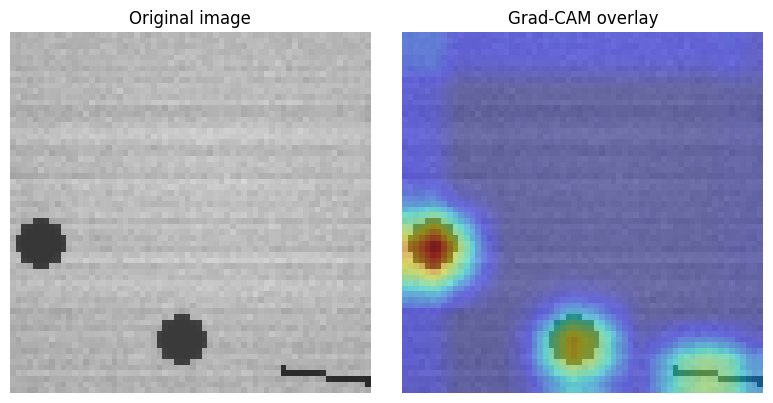

In [3]:
heatmap = make_gradcam_heatmap(batch, model, pred_index=pred_idx)
overlay = overlay_heatmap(heatmap, arr.astype('uint8'))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(arr.astype('uint8'))
axes[0].set_title('Original image')
axes[0].axis('off')
axes[1].imshow(overlay)
axes[1].set_title('Grad-CAM overlay')
axes[1].axis('off')
plt.tight_layout()
plt.show()

**Observation:** the bright red/yellow region in the heatmap sits directly on top of the scratch/dent — confirming the model learned the actual defect location, not some unrelated background pattern.

## Grad-CAM across multiple samples (good + defective)
A broader check across several images of both classes.

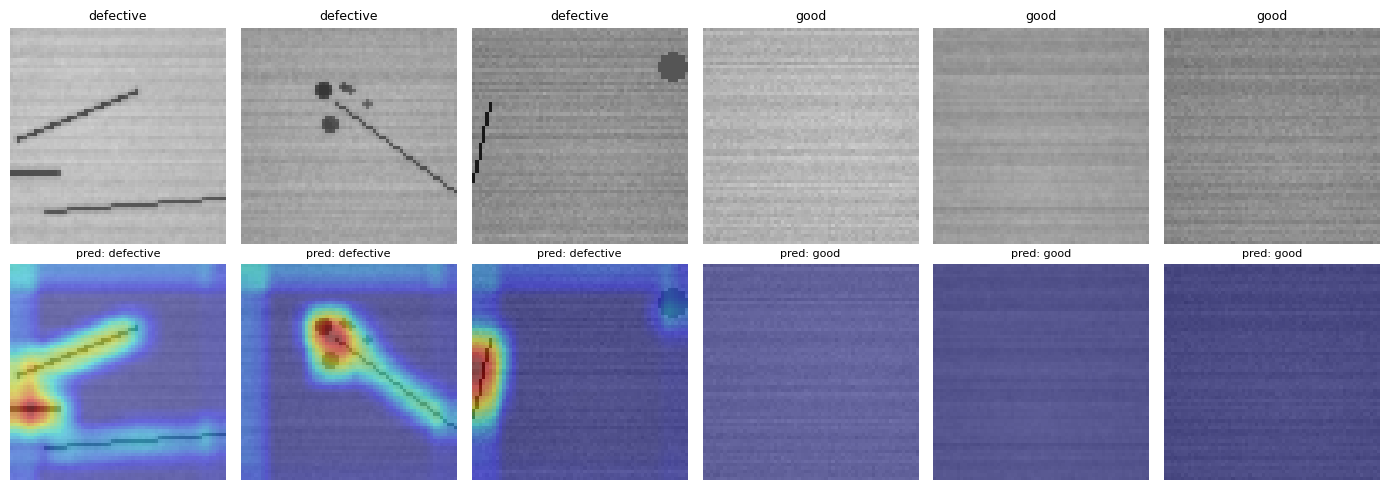

In [4]:
rng = np.random.default_rng(7)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for col, cls in enumerate(['defective']*3 + ['good']*3):
    files = sorted((test_dir / cls).glob('*.png'))
    f = files[rng.integers(0, len(files))]
    img = Image.open(f).convert('RGB').resize(target_size)
    arr = np.array(img).astype('float32')
    batch = arr[np.newaxis, ...]
    probs = model.predict(batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    heatmap = make_gradcam_heatmap(batch, model, pred_index=pred_idx)
    overlay = overlay_heatmap(heatmap, arr.astype('uint8'))

    axes[0, col].imshow(arr.astype('uint8'))
    axes[0, col].axis('off')
    axes[0, col].set_title(cls, fontsize=9)
    axes[1, col].imshow(overlay)
    axes[1, col].axis('off')
    axes[1, col].set_title(f'pred: {class_names[pred_idx]}', fontsize=8)

plt.tight_layout()
plt.show()

**Next step:** `04_evaluation.ipynb` — full test-set metrics and the business cost report (savings vs. manual inspection).